In [ ]:
import pandas as pd
import os
from sklearn.utils import resample
from sklearn.preprocessing import LabelEncoder

# 1. Load Original Data
old_fake = pd.read_csv("/content/drive/MyDrive/hajj_processing_workspace/fake_data_ready.csv")
old_real = pd.read_csv("/content/drive/MyDrive/hajj_processing_workspace/real_data_ready.csv")

# 2. Load the 900 "Smart" Fakes
ckpt_path = "/content/drive/MyDrive/hajj_processing_workspace/advanced_fake_generation/checkpoints"
new_fake_files = sorted([f for f in os.listdir(ckpt_path) if f.endswith('.csv')])
new_fake_df = pd.concat([pd.read_csv(os.path.join(ckpt_path, f)) for f in new_fake_files], ignore_index=True).iloc[:900]

# 3. Combine All Fakes
all_fakes = pd.concat([old_fake, new_fake_df], ignore_index=True)
print(f"Total Fakes: {len(all_fakes)}")

# 4. Balancing (Oversampling Real to match Fakes)
# 
real_augmented = resample(old_real, replace=True, n_samples=len(all_fakes), random_state=42)

# 5. Create master_v2
master_v2 = pd.concat([all_fakes, real_augmented], ignore_index=True)

# Combine Text + Image Description for a single context
master_v2['Full_Context'] = (
    master_v2['Text Content'].fillna('') + " " + 
    master_v2['Image Description'].fillna('')
)

# Label Encoding
le = LabelEncoder()
master_v2['Label_Encoded'] = le.fit_transform(master_v2['Label'])

print(f"Master Data Ready: {len(master_v2)} balanced samples.")

# SVM Model

In [30]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score
from nltk.stem.isri import ISRIStemmer
import nltk
import re

nltk.download('punkt')

st = ISRIStemmer()

def arabic_clean_and_stem(text):
    # 1. Clean (Remove symbols and numbers)
    text = re.sub(r'[^\w\s]', '', str(text))
    # 2. Tokenize & Stem
    tokens = nltk.word_tokenize(text)
    stemmed_words = [st.stem(w) for w in tokens]
    return " ".join(stemmed_words)

print("Stemming Function Ready.")

Stemming Function Ready.


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [32]:
import nltk
nltk.download('punkt_tab')

# Assuming master_v2 is already created from the previous step
# Applying Stemming to the whole dataset
print("Applying Stemming to total data (this might take a minute)...")
master_v2['Stemmed_Context'] = master_v2['Full_Context'].apply(arabic_clean_and_stem)

X = master_v2['Stemmed_Context']
y = master_v2['Label']

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Total samples for SVM: {len(X)}")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Applying Stemming to total data (this might take a minute)...
Total samples for SVM: 3692


In [45]:
from sklearn.pipeline import Pipeline

# 1. Define Pipeline
# Using Tfidf with 1-2 n-grams to capture phrases
svm_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=350, ngram_range=(1, 2))),
    ('svm', SVC(kernel='rbf', C=0.05, probability=False, random_state=42))
])

# 2. Train the Model
print("Training SVM Pipeline...")
svm_pipeline.fit(X_train, y_train)

# 3. Initial Evaluation
y_pred = svm_pipeline.predict(X_test)
print(f"\n--- SVM Model Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Training SVM Pipeline...

--- SVM Model Performance ---
Accuracy: 96.75%

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.94      0.97       370
  Suspicious       0.94      1.00      0.97       369

    accuracy                           0.97       739
   macro avg       0.97      0.97      0.97       739
weighted avg       0.97      0.97      0.97       739



In [46]:
import joblib
import os

save_path_svm = "/content/drive/MyDrive/hajj_processing_workspace/svm97"
os.makedirs(save_path_svm, exist_ok=True)

joblib.dump(svm_pipeline, f"{save_path_svm}/svm97_model.pkl")

joblib.dump(le, f"{save_path_svm}/label_encoder_svm.pkl")

print(f" SVM Model Pipeline saved successfully at: {save_path_svm}")

 SVM Model Pipeline saved successfully at: /content/drive/MyDrive/hajj_processing_workspace/svm97


# Arabert Model

In [2]:
!pip install transformers[torch] datasets arabert
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from arabert.preprocess import ArabertPreprocessor
from datasets import Dataset

# Check GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using Device: {device}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.0/185.0 kB 16.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.4/126.4 kB 7.7 MB/s eta 0:00:00
  Created wheel for emoji: filename=emoji-1.4.2-py3-none-any.whl size=186456 sha256=c4fbf6d47797a1a75b142ab5ca8d5284bdb854182ef4a213a2bfe74c07578132
  Stored in directory: /root/.cache/pip/wheels/bb/f1/26/f9002669ef6ad80a3c9f1b22880b35d9b4c6650011acee0523
Successfully built emoji
Using Device: cuda


In [1]:
from google.colab import drive
drive.mount("/content/drive")

import os

DRIVE_DIR = "/content/drive/MyDrive/hajj_real_data"
os.makedirs(DRIVE_DIR, exist_ok=True)

IMAGES_DIR = os.path.join(DRIVE_DIR, "images")
os.makedirs(IMAGES_DIR, exist_ok=True)

CSV_PATH = os.path.join(DRIVE_DIR, "real_data.csv")

print(f"[OK] drive connected")
print(f"[OK] csv path: {CSV_PATH}")
print(f"[OK] images path: {IMAGES_DIR}")


Mounted at /content/drive
[OK] drive connected
[OK] csv path: /content/drive/MyDrive/hajj_real_data/real_data.csv
[OK] images path: /content/drive/MyDrive/hajj_real_data/images


In [24]:
import pandas as pd
from sklearn.utils import resample

# 1. Load Old Data
old_fake = pd.read_csv("/content/drive/MyDrive/hajj_processing_workspace/fake_data_ready.csv")
old_real = pd.read_csv("/content/drive/MyDrive/hajj_processing_workspace/real_data_ready.csv")

# 2. Load New 900 Fakes (The Smart Ones)
# Assuming they are in the checkpoints folder we discussed
ckpt_path = "/content/drive/MyDrive/hajj_processing_workspace/advanced_fake_generation/checkpoints"
new_fake_files = sorted([f for f in os.listdir(ckpt_path) if f.endswith('.csv')])
new_fake_df = pd.concat([pd.read_csv(os.path.join(ckpt_path, f)) for f in new_fake_files], ignore_index=True).iloc[:900]

# 3. Combine All Fakes
all_fakes = pd.concat([old_fake, new_fake_df], ignore_index=True)
print(f"Total Fakes now: {len(all_fakes)}")

# 4. Data Augmentation (Oversampling Real to match Fakes)
# We need Legitimate count = Suspicious count
real_augmented = resample(old_real, replace=True, n_samples=len(all_fakes), random_state=42)

# 5. Final Balanced Master Dataset
master_v2 = pd.concat([all_fakes, real_augmented], ignore_index=True)
master_v2['Full_Context'] = master_v2['Text Content'].fillna('') + " " + master_new_df['Image Description'].fillna('')
master_v2['Bert_Processed'] = master_v2['Full_Context'].apply(lambda x: preprocessor.preprocess(x))
master_v2['Label_Encoded'] = le.fit_transform(master_v2['Label'])

print(f"Total Balanced Samples for Model 2: {len(master_v2)}")

Total Fakes now: 1846
Total Balanced Samples for Model 2: 3692


In [25]:
from transformers import TrainingArguments, Trainer

# Prepare Dataset
dataset_v2 = Dataset.from_pandas(master_v2[['Bert_Processed', 'Label_Encoded']])
dataset_v2 = dataset_v2.rename_column("Label_Encoded", "label").rename_column("Bert_Processed", "text")
dataset_v2 = dataset_v2.train_test_split(test_size=0.1, seed=42)
tokenized_v2 = dataset_v2.map(tokenize_function, batched=True)

# Training Args for 2 Epochs
training_args_v2 = TrainingArguments(
    output_dir="./arabert_model_v2",
    num_train_epochs=2,              # Just 2 epochs as requested
    learning_rate=1e-5,              # Very low to fine-tune existing knowledge
    per_device_train_batch_size=16,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    weight_decay=0.05,               # Higher decay to prevent overfitting to old data
    report_to="none"
)

trainer_v2 = Trainer(
    model=model, # Starting from current model state
    args=training_args_v2,
    train_dataset=tokenized_v2["train"],
    eval_dataset=tokenized_v2["test"],
    data_collator=data_collator
)

print("Starting Model 2 Refresher Training...")
trainer_v2.train()

Map:   0%|          | 0/3322 [00:00<?, ? examples/s]

Map:   0%|          | 0/370 [00:00<?, ? examples/s]

Starting Model 2 Refresher Training...


Epoch,Training Loss,Validation Loss
1,No log,0.001542
2,No log,0.000525


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=416, training_loss=0.008727547067862291, metrics={'train_runtime': 223.4558, 'train_samples_per_second': 29.733, 'train_steps_per_second': 1.862, 'total_flos': 437027462952960.0, 'train_loss': 0.008727547067862291, 'epoch': 2.0})

In [26]:
# Test on the same tricky scam ad
label_v2, score_v2 = predict_ad(scam_ad_text, scam_image_desc)

print("=" * 40)
print(f"MODEL 2 RESULT ON SMART SCAM:")
print(f"PREDICTION: {label_v2}")
print(f"CONFIDENCE: {score_v2:.2f}%")
print("=" * 40)

MODEL 2 RESULT ON SMART SCAM:
PREDICTION: Suspicious
CONFIDENCE: 99.97%


In [27]:
# --- تجربة العينة الحقيقية (تروبيك للسياحة) على الموديل المحدث ---
legit_ad_text = """حج بكل هدوء وتركيز في العبادة مع تروبيك للسياحة 🕋✨
معنا كل وسائل الانتقال مجهزة خصيصاً لخدمة وراحة حجاجنا
سواء كان قطار الحرمين السريع ،أو فخامة سيارات الـ GMC، أو راحة باصاتنا الحديثة.. طريقك للمشاعر مليئ بالراحة 🧡
راحتك في الطريق، قبل الوصول هدفنا 💙
تروبيك للسياحة .. رحلة حج وعمرة لقلب مطمئن
#تروبيك_للسياحة
#بِثِقَةٍ_نَصِلُ_وبِأَثَرٍ_نَبْقَىٰ
#رحلة_حج_وعمرة_لقلب_مطمئن
#حج_1447هـ"""

legit_image_desc = "اتوبيس سياح امام جبل كبير"

# تشغيل التنبؤ بالموديل V2
label_legit, score_legit = predict_ad(legit_ad_text, legit_image_desc)

print("-" * 40)
print(f"TESTING LEGITIMATE AD (Model V2)...")
print(f"RESULT: {label_legit}")
print(f"CONFIDENCE: {score_legit:.2f}%")
print("-" * 40)

----------------------------------------
TESTING LEGITIMATE AD (Model V2)...
RESULT: Legitimate
CONFIDENCE: 99.93%
----------------------------------------


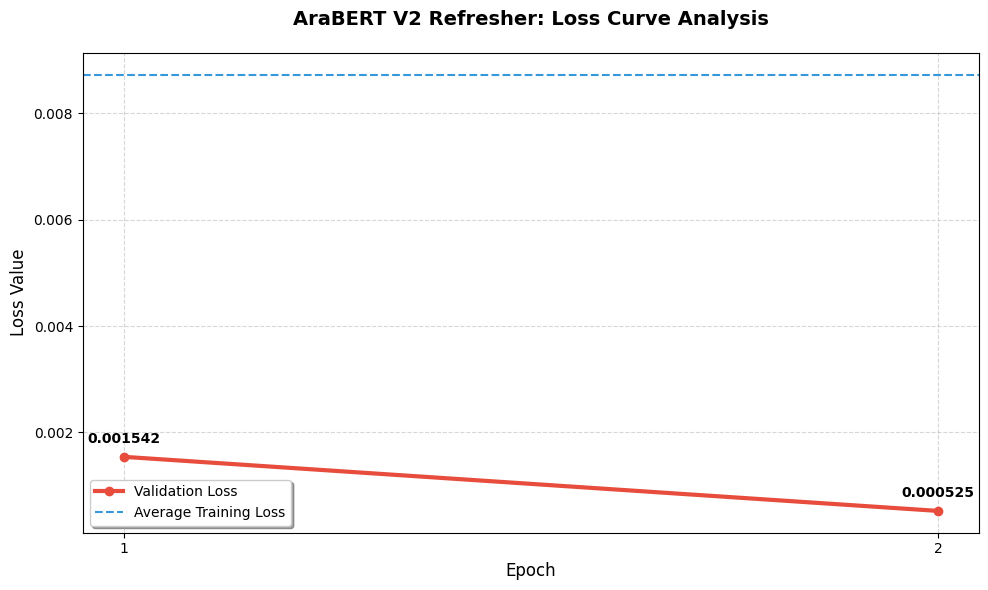

In [28]:
import matplotlib.pyplot as plt

# Data from your training logs
epochs = [1, 2]
val_loss = [0.001542, 0.000525]
avg_train_loss = 0.008727  # Final reported training loss

plt.figure(figsize=(10, 6))

# Plot Validation Loss
plt.plot(epochs, val_loss, marker='o', linestyle='-', color='#e74c3c', linewidth=3, label='Validation Loss')

# Plot a horizontal line for average training loss to show the gap
plt.axhline(y=avg_train_loss, color='#3498db', linestyle='--', label='Average Training Loss')

# Annotating the points
for i, txt in enumerate(val_loss):
    plt.annotate(f"{txt:.6f}", (epochs[i], val_loss[i]), textcoords="offset points", xytext=(0,10), ha='center', fontsize=10, fontweight='bold')

# Styling
plt.title('AraBERT V2 Refresher: Loss Curve Analysis', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss Value', fontsize=12)
plt.xticks(epochs)
plt.legend(frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

In [29]:
import os
import joblib

save_path = "/content/drive/MyDrive/hajj_processing_workspace/arabert_fine_tuning"
os.makedirs(save_path, exist_ok=True)

trainer_v2.save_model(save_path)

tokenizer.save_pretrained(save_path)

joblib.dump(le, f"{save_path}/label_encoder.pkl")

print(f"Done Save in : {save_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Done Save in : /content/drive/MyDrive/hajj_processing_workspace/arabert_fine_tuning
